In [6]:
import pandas as pd

df = pd.read_csv('../data/simulated_neutrino_events.csv')

X = df.drop('label', axis=1)
y = df['label']

print(X.shape, y.shape)
df.head()

(10000, 7) (10000,)


,energy,zenith,azimuth,track_length,dom_hits,reco_quality,time_spread,label
0,98.081446,1.442197,0.029931,126.207855,34,0.485269,93.527534,0
1,1061.817057,1.389104,2.025740,242.490299,49,0.589979,140.242079,0
2,751.236700,2.084102,4.949211,145.476823,70,0.631971,82.755329,0
3,2532.233961,0.680271,2.724317,168.049391,48,0.608734,96.381053,0
4,365.898764,1.463274,3.163519,165.080443,44,0.690437,107.537414,0


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

print('train', X_train.shape)
print('test', X_test.shape)
print('training label distribution', y_train.value_counts().to_dict)
print('test label distribution', y_test.value_counts().to_dict)

train (8000, 7)
test (2000, 7)
training label distribution <bound method Series.to_dict of label
0    6400
1    1600
Name: count, dtype: int64>
test label distribution <bound method Series.to_dict of label
0    1600
1     400
Name: count, dtype: int64>


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

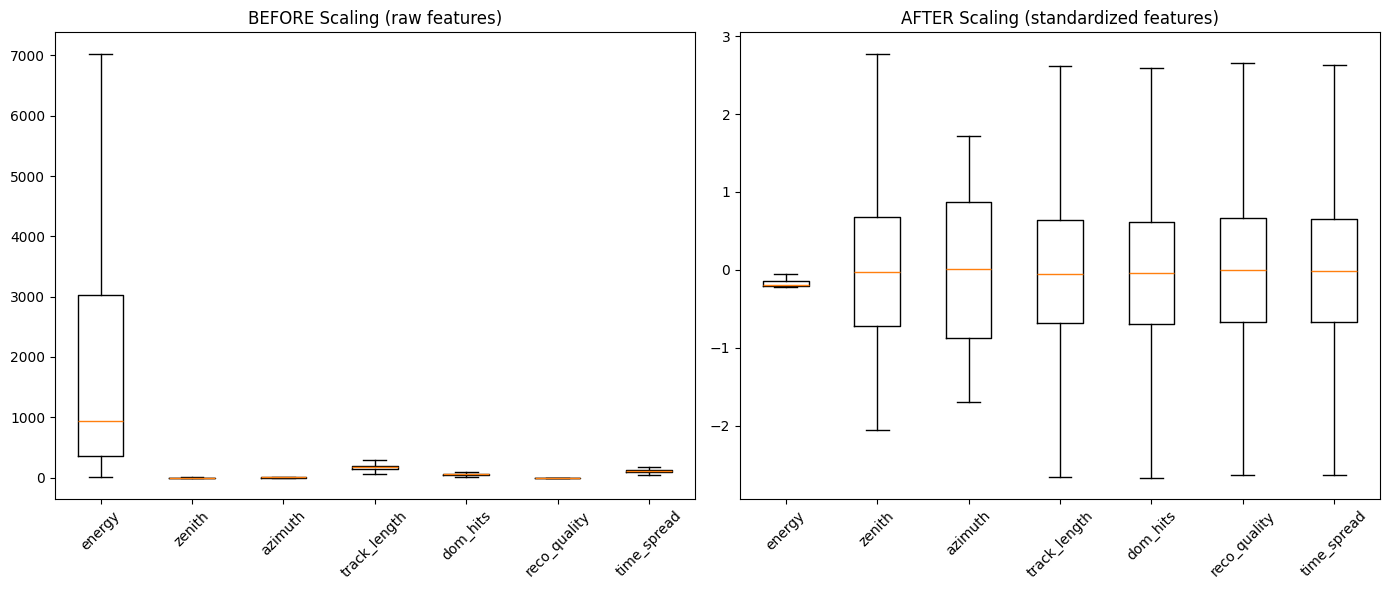

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
axes[0].boxplot([X_train[col] for col in X_train.columns], tick_labels=X_train.columns, showfliers=False)
axes[0].set_title('BEFORE Scaling (raw features)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].boxplot([X_train_scaled_df[col] for col in X_train_scaled_df.columns], tick_labels=X_train_scaled_df.columns, showfliers=False)
axes[1].set_title('AFTER Scaling (standardized features)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()